In [1]:
import jax.random as random
from functools import partial
import itertools
import jax.numpy as jnp
import jax
from jax.nn import softmax
import matplotlib.pyplot as plt
from jax import vmap

In [2]:
base_key = random.key(0)
keys = map(partial(random.fold_in, base_key), itertools.count())

eps = 0.1
Sig = eps * jnp.ones((2,2))

L = jnp.linalg.cholesky(Sig)
print(L)

random.normal(next(keys), (100, 2))

[[nan  0.]
 [nan nan]]


Array([[ 1.0040143 , -0.9063372 ],
       [-0.7481722 , -1.1713669 ],
       [-0.8712328 ,  0.5888381 ],
       [ 0.72392994, -1.0255982 ],
       [ 1.661628  , -1.8910251 ],
       [-1.2889339 ,  0.13360691],
       [-1.1530392 ,  0.23929629],
       [ 1.7448074 ,  0.5050189 ],
       [ 0.595053  , -0.47283807],
       [ 0.9156375 ,  0.3612034 ],
       [-0.63416433, -0.870491  ],
       [ 0.7583879 ,  1.0628535 ],
       [ 0.90835655, -0.49232015],
       [ 0.88849205,  1.6453909 ],
       [-2.5158658 ,  0.4417807 ],
       [ 1.8173127 , -1.1731389 ],
       [-0.5887164 ,  2.146985  ],
       [ 0.80188036, -0.19745427],
       [-1.7398049 , -0.8214191 ],
       [-2.362677  ,  1.5526493 ],
       [ 1.405427  ,  0.35037923],
       [ 0.06246307,  1.1470388 ],
       [-0.21245524, -0.33967492],
       [ 0.6888535 , -0.33923876],
       [ 0.49200532,  0.21159482],
       [-1.8126068 ,  1.8841707 ],
       [ 0.84517723,  1.6877822 ],
       [ 1.6461896 , -0.77160335],
       [ 1.2086458 ,

In [24]:
base_key = random.key(0)
keys = map(partial(random.fold_in, base_key), itertools.count())

B = 10
N = 5
K = 3



logits = random.normal(next(keys), (B, K))

random.categorical(next(keys), logits = logits, axis = -1, shape = (B, N))

ValueError: Incompatible shapes for broadcasting: shapes=[(10, 5), (np.int64(10),)]

In [ ]:
base_key = key = random.key(0)
keys = map(partial(random.fold_in, base_key), itertools.count())
B, K, MC_samps, d = 4, 3, 3, 2
eps = random.normal(next(keys), (B, MC_samps, d))
Ls = random.normal(next(keys), (B, 1, d, d))

print(jnp.einsum("tnij, tnj->tni", Ls, eps))

[[[-2.245891    2.1654487 ]
  [ 1.6735951   2.7986658 ]
  [ 1.9488707  -1.4068701 ]]

 [[-1.3828464   0.9039479 ]
  [-3.1740313   1.6667231 ]
  [ 2.4621134  -0.11775927]]

 [[ 1.7296836   0.7404341 ]
  [-2.6174      1.5626369 ]
  [-0.8926439  -1.4630625 ]]

 [[-1.5328673  -0.11049325]
  [ 1.0616535   0.26628593]
  [-1.2696161  -0.3251302 ]]]


In [ ]:
base_key = key = random.key(0)
keys = map(partial(random.fold_in, base_key), itertools.count())

means = 4*random.normal(next(keys), (4,))
stds = 2*random.gamma(next(keys), 2, (4,))
ws = random.dirichlet(next(keys), jnp.ones(2))

def sample_pc():

    u = random.uniform(next(keys), (1,))

    if u < ws[0]:
        x = means[:2] + stds[:2] * random.normal(next(keys), (2,))

    else:
        x = means[2:] + stds[2:] * random.normal(next(keys), (2,))

    return x

x = sample_pc()
print(means, stds, ws)

[ 4.016057  -3.6253488 -2.992689  -4.6854677] [7.865243  0.562248  1.1192235 1.995118 ] [0.4618669  0.53813314]


In [28]:
samps = []
n = 10000
for i in range(n):
    samps.append(sample_pc())

samps = jnp.stack(samps, axis=0)


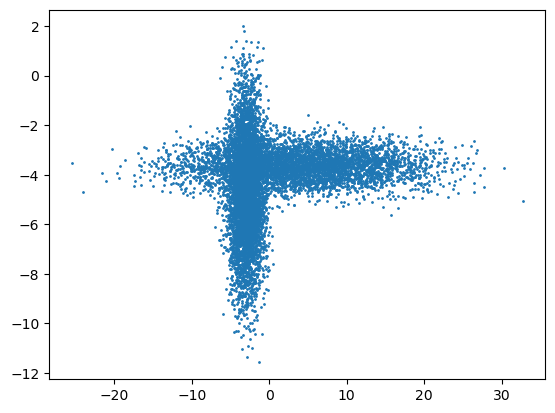

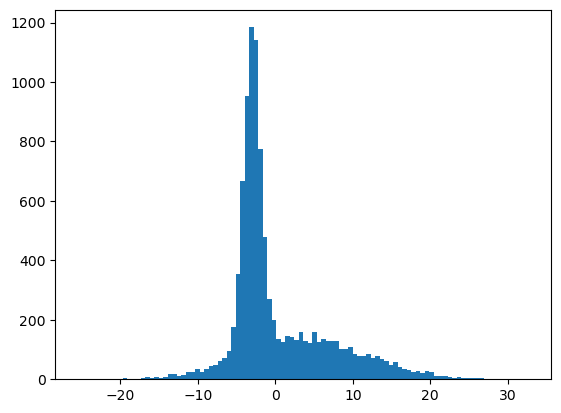

In [29]:
plt.scatter(samps[:, 0], samps[:, 1], s = 1)
plt.show()
plt.hist(samps[:, 0], bins=100)
plt.show()

In [26]:
key = random.key(2)
n = 1500
m = 2000

def f(x):
    return 1/(1+x)

def g(x):
    return 1+x

u = random.uniform(key, (n,m))

Is = jax.vmap(f, in_axes=1, out_axes=1)(u).mean(axis=0)

Is_ctrl = Is + 0.4773 * (jax.vmap(g, in_axes=1, out_axes=1)(u).mean(axis=0) - 3/2)

print(Is[0], Is.mean(axis=0), Is.var(axis=0), Is_ctrl[0], Is_ctrl.mean(axis=0),Is_ctrl.var(axis=0), jnp.log(2))

0.69922054 0.6929556 1.2837246e-05 0.69361365 0.69310683 3.9635452e-07 0.6931472


In [55]:
x = itertools.count()

In [59]:
next(x)

3

In [52]:
print(next(key))
print(next(key))

Array((), dtype=key<fry>) overlaying:
[696157669 338758650]
Array((), dtype=key<fry>) overlaying:
[ 564312718 1183406840]


In [37]:
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import norm


In [38]:
def logistic(x, x0, alpha):
    # y \approx 1(x < x0)
    y = 1 / (1 + np.e**(alpha*(x-x0)))

    return y



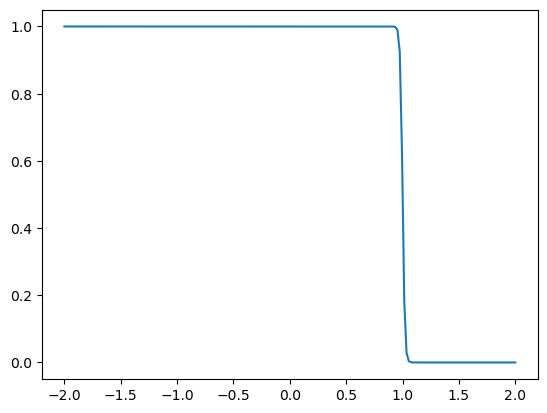

In [39]:
x = np.linspace(-2,2, 200)
y = logistic(x, x0=1, alpha=100)

plt.plot(x,y)

In [40]:
n = 5000
ys = np.random.normal(0,1, (1,n))
ys = np.sort(ys)



In [41]:
def softmax_ecdf(ys, alpha):
    K = ys.shape[1]

    sum_logs = logistic(ys, ys.reshape(n,1), alpha=alpha).sum(axis=-1)
    ecdf = ( sum_logs + 0.5 ) / K

    return ecdf

ecdf = softmax_ecdf(ys, alpha=500)



/var/folders/rm/lcltb3c50vgc_vn2gmq557hr0000gn/T/ipykernel_46099/4193084553.py:3: RuntimeWarning: overflow encountered in power
  y = 1 / (1 + np.e**(alpha*(x-x0)))


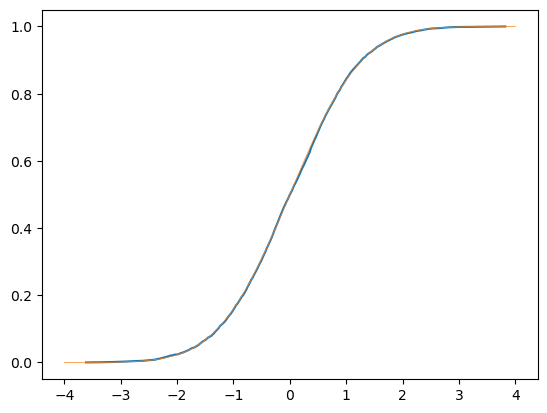

In [42]:
plt.plot(ys.squeeze(0), ecdf)
x = np.linspace(-4, 4); cdf = norm.cdf(x)
plt.plot(x, cdf, linewidth= 0.5)